# Example 2: Visualizations

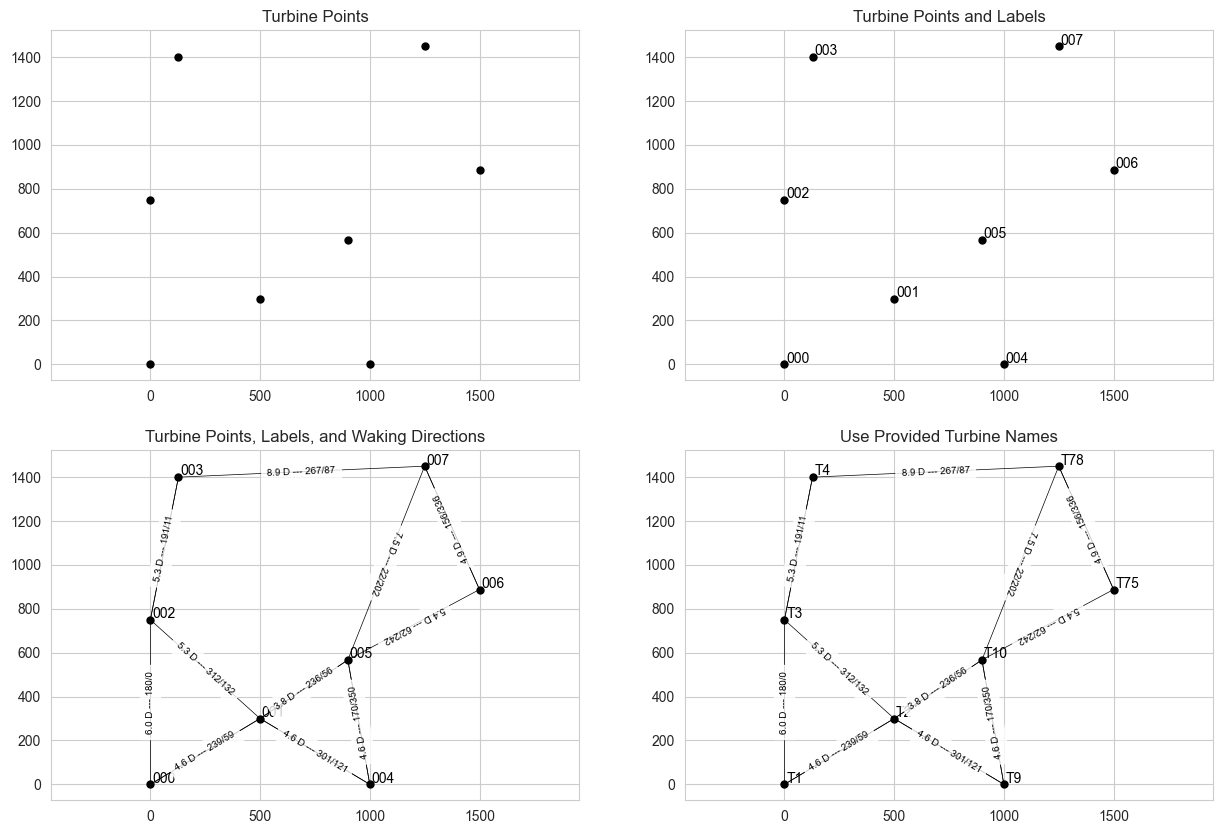

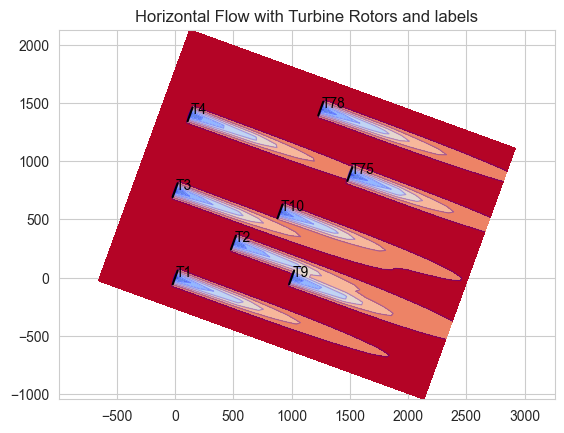

In [1]:
"""Example 2: Visualizations

This example demonstrates the use of the flow and layout visualizations in FLORIS.
First, an example wind farm layout is plotted, with the turbine names and the directions
and distances between turbines shown in different configurations by subplot.
Next, the horizontal flow field at hub height is plotted for a single wind condition.

FLORIS includes two modules for visualization:
  1) flow_visualization: for visualizing the flow field
  2) layout_visualization: for visualizing the layout of the wind farm
The two modules can be used together to visualize the flow field and the layout
of the wind farm.

"""


import matplotlib.pyplot as plt

import floris.layout_visualization as layoutviz
from floris import FlorisModel
from floris.flow_visualization import visualize_cut_plane


fmodel = FlorisModel("inputs/gch.yaml")

# Set the farm layout to have 8 turbines irregularly placed
layout_x = [0, 500, 0, 128, 1000, 900, 1500, 1250]
layout_y = [0, 300, 750, 1400, 0, 567, 888, 1450]
fmodel.set(layout_x=layout_x, layout_y=layout_y)


# Layout visualization contains the functions for visualizing the layout:
# plot_turbine_points
# plot_turbine_labels
# plot_turbine_rotors
# plot_waking_directions
# Each of which can be overlaid to provide further information about the layout
# This series of 4 subplots shows the different ways to visualize the layout

# Create the plotting objects using matplotlib
fig, axarr = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axarr = axarr.flatten()

ax = axarr[0]
layoutviz.plot_turbine_points(fmodel, ax=ax)
ax.set_title("Turbine Points")

ax = axarr[1]
layoutviz.plot_turbine_points(fmodel, ax=ax)
layoutviz.plot_turbine_labels(fmodel, ax=ax)
ax.set_title("Turbine Points and Labels")

ax = axarr[2]
layoutviz.plot_turbine_points(fmodel, ax=ax)
layoutviz.plot_turbine_labels(fmodel, ax=ax)
layoutviz.plot_waking_directions(fmodel, ax=ax, limit_num=2)
ax.set_title("Turbine Points, Labels, and Waking Directions")

# In the final subplot, use provided turbine names in place of the t_index
ax = axarr[3]
turbine_names = ["T1", "T2", "T3", "T4", "T9", "T10", "T75", "T78"]
layoutviz.plot_turbine_points(fmodel, ax=ax)
layoutviz.plot_turbine_labels(fmodel, ax=ax, turbine_names=turbine_names)
layoutviz.plot_waking_directions(fmodel, ax=ax, limit_num=2)
ax.set_title("Use Provided Turbine Names")


# Visualizations of the flow field are made by using calculate plane methods.  In this example
# we show the horizontal plane at hub height, further examples are provided within
# the examples_visualizations folder

# For flow visualizations, the FlorisModel may be set to run a single condition
# (n_findex = 1). Otherwise, the user may set multiple conditions and then use
# the findex_for_viz keyword argument to calculate_horizontal_plane to specify which
# flow condition to visualize.
fmodel.set(wind_speeds=[8.0], wind_directions=[290.0], turbulence_intensities=[0.06])
horizontal_plane = fmodel.calculate_horizontal_plane(
    x_resolution=200,
    y_resolution=100,
    height=90.0,
)

# Plot the flow field with rotors
fig, ax = plt.subplots()
visualize_cut_plane(
    horizontal_plane,
    ax=ax,
    label_contours=False,
    title="Horizontal Flow with Turbine Rotors and labels",
)

# Plot the turbine rotors
layoutviz.plot_turbine_rotors(fmodel, ax=ax)
layoutviz.plot_turbine_labels(fmodel, ax=ax, turbine_names=turbine_names)

plt.show()
import warnings
warnings.filterwarnings('ignore')